# Example: DAQ Module in Contunous Mode for MFLI

Instrument: MFLI

module: DAQ

option: Vanilla

Author: Mehdi Alem

Copyright 2021 Zurich Instruments AG

Connection: Signal Output +V -> Signa Input +V with a BNC cable

In [2]:
import zhinst.core
import time
import matplotlib.pyplot as plt

### Device and data server connection

In [3]:
# Create an API session to the data server and instrument 

# Device serial number
device = "DEV1004"

# Server address when running on the device (depends on the medium of connection, i.e. USB or Ethernet)
server = 'localhost' 
interface = 'PCIe'

# Server address for proxy connection (required for MDS)
#server = '127.0.0.1'
#interface = '1GbE'

# Create an API session to the data server 
daq = zhinst.core.ziDAQServer(server, 8004, 6)

# Connect the data server to the device via data server 
daq.connectDevice(device, interface)

DeviceNotFoundError: ZIAPIServerException with status code: 32788 - Device is not visible to the server. Extended information: No device found with id DEV1004.

### Device settings

In [3]:
# Enabling the data transfer of demodulator 1
daq.setInt(f'/{device}/demods/0/enable', 1)

# Set the transfer rate of demodulator samples 
daq.setDouble(f'/{device}/demods/0/rate', 50e3)

# Setting the frequency of oscillators 1 and 2
daq.setDouble(f'/{device}/oscs/0/freq', 1e3)

# Assigning oscillators to their corresponding demodulators
daq.setInt(f'/{device}/demods/0/oscselect', 0)

# Setting the filter order and bandwidth of demodulator 1
daq.setInt(f'/{device}/demods/0/order', 3)
daq.setDouble(f'/{device}/demods/0/timeconstant', 40e-06)

# 50-ohm input impedance
daq.setInt(f'/{device}/sigins/0/imp50', 1)

# Enabling and setting the amplitude of signal output
daq.setDouble(f'/{device}/sigouts/0/amplitudes/1', 0.1)
daq.setInt(f'/{device}/sigouts/0/enables/1', 1)
daq.setInt(f'/{device}/sigouts/0/on', 1)

# Auto-ranging of signal input
daq.setInt(f'/{device}/sigins/0/autorange', 1)

# Ensure the changes are applied to the instrument
daq.sync()
time.sleep(1)

### Initialization of DAQ module

In [4]:
# DAQ module 
daq_module = None

# Image dimensions 
num_rows = 16
num_cols = 128

# Initialize the module
daq_module = daq.dataAcquisitionModule()

# Assign a device to the module 
daq_module.set('device', device)

# Type of measurement, 0:continuous mode 
daq_module.set('type', 0) 

# Grid mode and image size
daq_module.set('grid/mode', 4)
daq_module.set('grid/cols', num_cols)
daq_module.set('grid/rows', num_rows)

### Subscription to the signal path

In [5]:
# Path of desired signal: demodulation amplitude
node_path = f'/{device}/demods/0/sample.r.avg'

# Subscribe to the signal
daq_module.subscribe(node_path) 

### Signal acquisition

In [6]:
# Execute the DAQ module to acquire the measured signal 
daq_module.execute()

# Wait loop to finish the entire acquisition (not necessarily needed)
start= time.time()
while not daq_module.finished():
   time.sleep(0.2)
duration = time.time() - start
print("Finished in", duration, 's')

Finished in 1.003739833831787 s


### Reading out the data after execution

In [7]:
# Read data
data = daq_module.read(True)

# Clear the modul if not required anymore
daq_module.finish()
daq_module.clear()

### Extract time and signal 

In [8]:
# Get the device timebase for time calculation: 60 MHz 
clockbase = daq.getInt(f'/{device}/clockbase')

# Exctract time and signal from the data dictionary 
t = (data[node_path][0]['timestamp'][0,:] - data[node_path][0]['timestamp'][0,0]) / clockbase
R = data[node_path][0]['value']

### Plot the signal and image

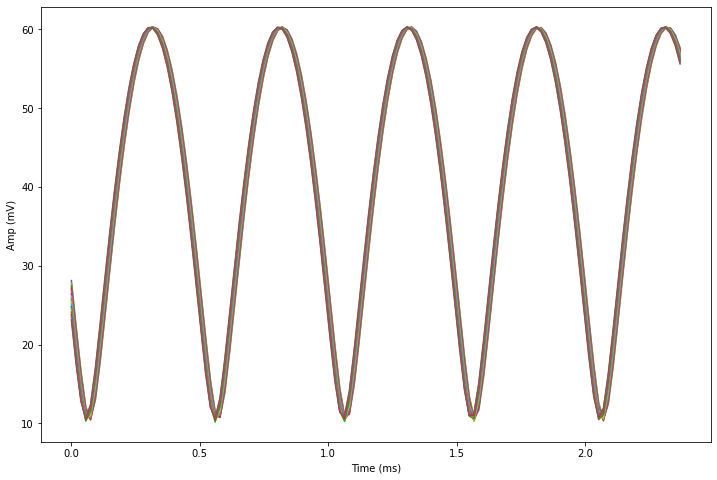

In [9]:
plt.figure(figsize=(12,8))
for row in range(num_rows):
    plt.plot(t*1e3, R[row,:]*1e3)
plt.xlabel('Time (ms)')
plt.ylabel('Amp (mV)')
plt.show()

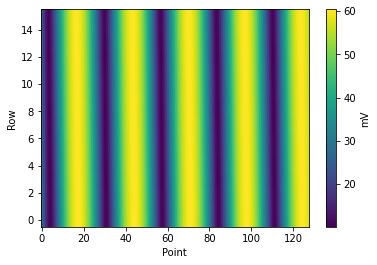

In [10]:
plt.figure()
im = plt.imshow(R*1e3, aspect='auto', origin='lower', alpha=True)
plt.xlabel('Point')
plt.ylabel('Row')
plt.colorbar(im, label='mV')
plt.show()